# 인공신경망으로 사인곡선 배우기

이 노트북은 **딥러닝을 처음 배우는 사람**을 위한 아주 작은 실습입니다. 인공신경망이 `x`를 입력받아 `sin(x)`를 예측하도록 직접 학습시켜 봅니다.

목표는 완벽한 수학 공식 암기가 아니라 다음 흐름을 이해하는 것입니다.

`데이터 준비 → 예측 → 오차 측정 → 가중치 수정 → 더 나은 예측`

> 실행 방법: 각 코드 셀을 위에서 아래 순서대로 `Shift + Enter`로 실행하세요. 처음에 라이브러리 오류가 나면 아래 설치 셀의 주석을 해제해 실행합니다.

## 1. 딥러닝과 인공신경망이란?

- **머신러닝**: 데이터를 보고 규칙을 찾게 하는 방법입니다.
- **딥러닝**: 인공신경망을 여러 층으로 쌓아 복잡한 규칙을 배우게 하는 머신러닝입니다.
- **인공신경망**: 작은 계산기(뉴런)를 연결한 모델입니다. 각 뉴런은 입력에 **가중치(weight)**를 곱하고, 값을 조금 조절한 뒤 다음 뉴런으로 넘깁니다.

이번 예제의 정답은 이미 아는 `sin(x)`입니다. 하지만 신경망에는 사인 공식 자체를 주지 않습니다. 많은 `(x, sin(x))` 예시만 보고 곡선 모양을 흉내 내게 합니다.

In [ ]:
# 필요 시 한 번만 실행하세요. (앞의 #을 지우고 실행)
# %pip install numpy matplotlib

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 같은 결과를 다시 볼 수 있도록 난수의 시작점을 고정합니다.
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## 2. 학습 데이터 만들기

입력 `x`는 0에서 $2π$까지의 숫자이고, 정답 `y`는 `sin(x)`입니다.

실제 프로젝트에서는 정답을 사람이 라벨링하거나 센서에서 얻습니다. 여기서는 교육용으로 NumPy의 사인 함수를 이용해 정답 데이터를 만듭니다.

x_train 모양: (200, 1)
y_train 모양: (200, 1)


C:\Users\dbvhf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dbvhf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dbvhf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dbvhf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dbvhf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4

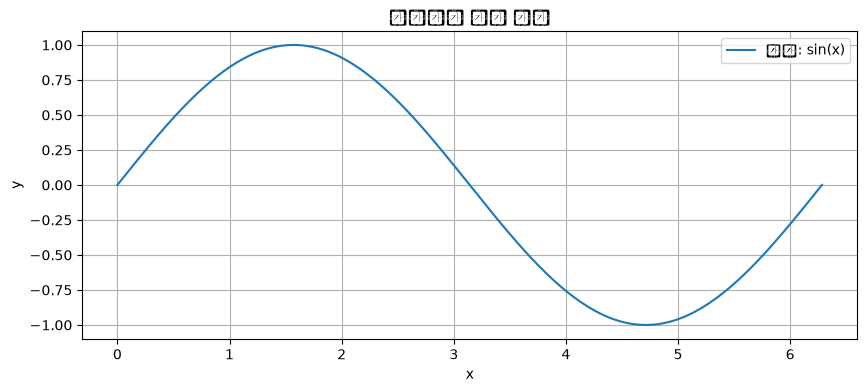

In [8]:
# 200개의 학습 예시. reshape(-1, 1)은 '(예시 수, 입력 특성 수)' 모양으로 만듭니다.
x_train = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
y_train = np.sin(x_train)

print('x_train 모양:', x_train.shape)
print('y_train 모양:', y_train.shape)

plt.plot(x_train, y_train, label='정답: sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('신경망이 배울 목표')
plt.legend()
plt.show()

## 3. 신경망의 구조

우리가 만들 모델은 다음과 같습니다.

`입력 x (1개) → 은닉층 뉴런 16개 → 출력 y (1개)`

은닉층에서는 `tanh`라는 **활성화 함수**를 씁니다. 활성화 함수가 없으면 여러 층을 쌓아도 결국 직선만 만들 수 있습니다. `tanh` 덕분에 신경망은 굽은 모양을 표현할 수 있습니다.

각 층의 계산은 `입력 @ 가중치 + 편향`입니다. 여기서 `@`는 행렬곱이고, **편향(bias)**은 전체 결과를 위아래로 옮겨 주는 값입니다.

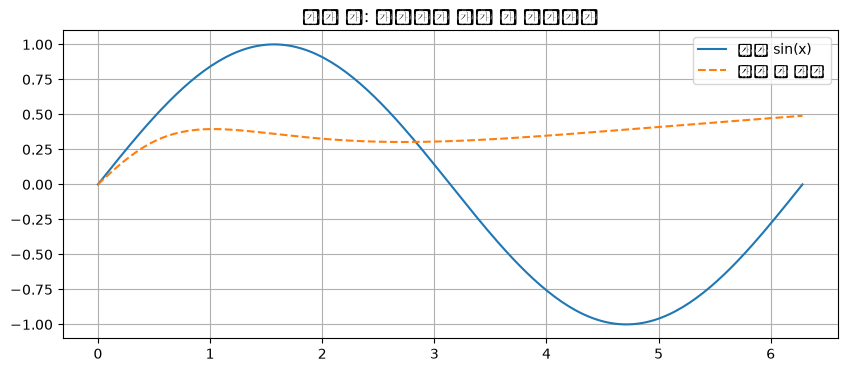

In [28]:
# 모델의 크기
input_size = 1
hidden_size = 30
output_size = 1

# 처음 가중치는 작은 무작위 값입니다. 아직 사인곡선을 전혀 모르는 상태입니다.
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

def forward(x):
    """입력 x로부터 예측값과, 학습에 필요한 중간값을 계산합니다."""
    z1 = x @ W1 + b1        # 은닉층으로 들어가기 전 값
    a1 = np.tanh(z1)        # 활성화된 은닉층 값
    prediction = a1 @ W2 + b2  # 최종 예측값
    return prediction, z1, a1

before, _, _ = forward(x_train)
plt.plot(x_train, y_train, label='정답 sin(x)')
plt.plot(x_train, before, '--', label='학습 전 예측')
plt.title('학습 전: 신경망은 아직 잘 모릅니다')
plt.legend()
plt.show()

## 4. 오차(loss)와 학습

예측이 정답과 얼마나 다른지 숫자로 나타낸 것이 **손실(loss)**입니다. 여기서는 평균제곱오차(MSE)를 사용합니다.

$$MSE = 평균((예측 - 정답)^2)$$

학습은 손실을 작게 하는 방향으로 가중치와 편향을 조금씩 바꾸는 일입니다. 이 수정 방향은 **역전파(backpropagation)**로 구하고, **경사하강법(gradient descent)**으로 실제 값을 업데이트합니다.

`learning_rate`는 한 번에 얼마나 크게 고칠지 정합니다. 너무 크면 불안정하고, 너무 작으면 학습이 매우 느립니다.

In [33]:
learning_rate = 0.03
epochs = 30000  # 데이터 전체를 학습하는 횟수
loss_history = []
n = len(x_train)

for epoch in range(epochs):
    # 1) 순전파: 현재 가중치로 예측
    prediction, z1, a1 = forward(x_train)

    # 2) 손실 계산
    loss = np.mean((prediction - y_train) ** 2)
    loss_history.append(loss)

    # 3) 역전파: 각 가중치를 어느 방향으로 바꿀지 계산
    d_prediction = 2 * (prediction - y_train) / n
    dW2 = a1.T @ d_prediction
    db2 = np.sum(d_prediction, axis=0, keepdims=True)
    d_a1 = d_prediction @ W2.T
    d_z1 = d_a1 * (1 - np.tanh(z1) ** 2)  # tanh의 미분
    dW1 = x_train.T @ d_z1
    db1 = np.sum(d_z1, axis=0, keepdims=True)

    # 4) 경사하강법: 손실을 줄이는 쪽으로 파라미터 수정
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 1000 == 0:
        print(f'epoch {epoch:4d} | MSE: {loss:.6f}')

print(f'최종 MSE: {loss_history[-1]:.6f}')

epoch    0 | MSE: 0.052077
epoch 1000 | MSE: 0.049882
epoch 2000 | MSE: 0.047613
epoch 3000 | MSE: 0.045329
epoch 4000 | MSE: 0.043058
epoch 5000 | MSE: 0.040792
epoch 6000 | MSE: 0.038516
epoch 7000 | MSE: 0.036219
epoch 8000 | MSE: 0.033900
epoch 9000 | MSE: 0.031570
epoch 10000 | MSE: 0.029246
epoch 11000 | MSE: 0.026953
epoch 12000 | MSE: 0.024716
epoch 13000 | MSE: 0.022558
epoch 14000 | MSE: 0.020499
epoch 15000 | MSE: 0.018555
epoch 16000 | MSE: 0.016735
epoch 17000 | MSE: 0.015047
epoch 18000 | MSE: 0.013497
epoch 19000 | MSE: 0.012094
epoch 20000 | MSE: 0.010844
epoch 21000 | MSE: 0.009744
epoch 22000 | MSE: 0.008779
epoch 23000 | MSE: 0.007929
epoch 24000 | MSE: 0.007176
epoch 25000 | MSE: 0.006505
epoch 26000 | MSE: 0.005906
epoch 27000 | MSE: 0.005370
epoch 28000 | MSE: 0.004891
epoch 29000 | MSE: 0.004464
최종 MSE: 0.004032


In [1]:
# 학습이 진행될수록 손실이 작아지는지 확인합니다.
plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('학습 과정: 오차가 줄어드는가?')
plt.show()

# 학습된 모델의 결과
prediction, _, _ = forward(x_train)
plt.plot(x_train, y_train, linewidth=3, label='정답 sin(x)')
plt.plot(x_train, prediction, '--', linewidth=2, label='신경망 예측')
plt.xlabel('x')
plt.ylabel('y')
plt.title('학습 후: 사인곡선을 근사한 결과')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

## 5. 처음 보는 입력에도 답할 수 있을까?

학습 때 사용하지 않았던 더 촘촘한 `x` 값을 넣어 봅니다. 이처럼 새 데이터에서 확인하는 과정을 **일반화 성능 평가**라고 합니다.

중요: 이 모델은 0부터 $2π$ 범위의 예시만 보고 배웠습니다. 그 범위 밖까지 잘 맞을 것이라고 기대하면 안 됩니다. 학습 데이터의 범위와 품질이 모델 성능을 크게 좌우합니다.

In [32]:
x_test = np.linspace(0, 2 * np.pi, 500).reshape(-1, 1)
y_test = np.sin(x_test)
test_prediction, _, _ = forward(x_test)
test_mse = np.mean((test_prediction - y_test) ** 2)

print(f'새 입력에서의 MSE: {test_mse:.6f}')
for x_value in [0, np.pi / 2, np.pi, 3 * np.pi / 2]:
    predicted, _, _ = forward(np.array([[x_value]]))
    print(f'x={x_value:.2f}, 정답={np.sin(x_value): .3f}, 예측={predicted.item(): .3f}')

새 입력에서의 MSE: 0.051319
x=0.00, 정답= 0.000, 예측= 0.047
x=1.57, 정답= 1.000, 예측= 0.944
x=3.14, 정답= 0.000, 예측=-0.287
x=4.71, 정답=-1.000, 예측=-0.880


## 6. 핵심 정리

1. 신경망은 정답 공식을 외우는 것이 아니라, 데이터에서 입력과 출력의 관계를 근사합니다.
2. 가중치와 편향은 모델이 학습하면서 바꾸는 값(파라미터)입니다.
3. 손실(loss)은 예측의 틀린 정도이고, 학습의 목표는 이 값을 줄이는 것입니다.
4. 역전파는 각 파라미터를 어떻게 바꿔야 손실이 줄어드는지 계산합니다.
5. 실제 딥러닝에서는 이 계산을 PyTorch 같은 도구가 대신 해 줍니다. 하지만 여기서는 원리를 보기 위해 NumPy로 직접 작성했습니다.

### 다음 실험

- `hidden_size = 4`, `16`, `64`로 바꾸고 결과를 비교해 보세요.
- `epochs` 또는 `learning_rate`를 바꾸고 손실 그래프를 관찰해 보세요.
- 학습 범위를 $0$~$2π$ 대신 $-2π$~$2π$로 바꿔 보세요.

SO101 프로젝트에서는 나중에 이런 방식으로 카메라 이미지나 로봇 관절 상태를 입력으로 사용하고, 로봇이 취할 동작을 출력으로 학습시킬 수 있습니다.